# Task-03: Decision Tree Classifier

## Objective

Build a decision tree classifier to predict whether a customer will purchase a product or service based on their demographic and behavioral data.

For this project, the **Bank Marketing dataset** is used. The target variable indicates whether a customer subscribed to a term deposit.

---

## Problem Statement

A bank conducts marketing campaigns to contact potential customers and promote its term-deposit products.

The goal of this project is to develop a machine learning model that can predict whether a customer is likely to subscribe to the term deposit based on information such as:

- Age
- Job
- Marital status
- Education
- Account balance
- Housing loan
- Personal loan
- Contact information
- Previous campaign outcomes
- Other demographic and behavioral attributes

The problem is treated as a **binary classification problem**, because the target variable has two possible outcomes:

- `yes` — customer subscribed
- `no` — customer did not subscribe

---

## Dataset

The dataset used for this project is the **Bank Marketing Dataset** from the UCI Machine Learning Repository.

The dataset contains information about customers and their interactions with the bank's marketing campaigns.

### Target Variable

The target variable is:

`y`

where:

- `yes` = customer subscribed to the term deposit
- `no` = customer did not subscribe to the term deposit

---

## Project Workflow

The project will follow these major steps:

1. Import required libraries
2. Load the dataset
3. Understand the dataset structure
4. Perform exploratory data analysis
5. Check and handle missing/unknown values
6. Prepare the features and target variable
7. Encode categorical variables
8. Split the dataset into training and testing sets
9. Build a Decision Tree Classifier
10. Train the model
11. Make predictions
12. Evaluate model performance
13. Analyze the confusion matrix
14. Analyze feature importance
15. Visualize the decision tree
16. Draw conclusions


## 1. Import Required Libraries

In this section, the libraries required for data manipulation, visualization, preprocessing, model building, and evaluation will be imported.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset



In [11]:
file="C:\\Users\\Admin\\Desktop\\tasks\\task 3\\bank\\bank_full.csv"
df = pd.read_csv("bank_full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 3. Understanding the Dataset


In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 45211
Number of columns: 17


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [14]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [16]:
df.describe(include="all")

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


In [17]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [18]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [20]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:20])


age:
[58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39]

job:
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital:
['married' 'single' 'divorced']

education:
['tertiary' 'secondary' 'unknown' 'primary']

default:
['no' 'yes']

balance:
[2143   29    2 1506    1  231  447  121  593  270  390    6   71  162
  229   13   52   60    0  723]

housing:
['yes' 'no']

loan:
['no' 'yes']

contact:
['unknown' 'cellular' 'telephone']

day:
[ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2]

month:
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

duration:
[261 151  76  92 198 139 217 380  50  55 222 137 517  71 174 353  98  38
 219  54]

campaign:
[ 1  2  3  5  4  6  7  8  9 10 11 12 13 19 14 24 16 32 18 22]

pdays:
[ -1 151 166  91  86 143 147  89 140 176 101 174 170 167 195 165 129 188
 196 172]

previous:
[ 0  3  1  4  2 11 16  6  5 10 12 

## 4. Exploratory Data Analysis

In [21]:
print(df["y"].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


In [22]:
print(df["y"].value_counts(normalize=True) * 100)

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


### Target Variable Visualization

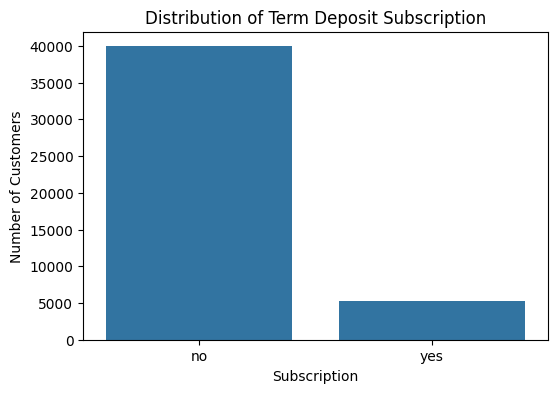

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="y")

plt.title("Distribution of Term Deposit Subscription")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

### Age Distribution 

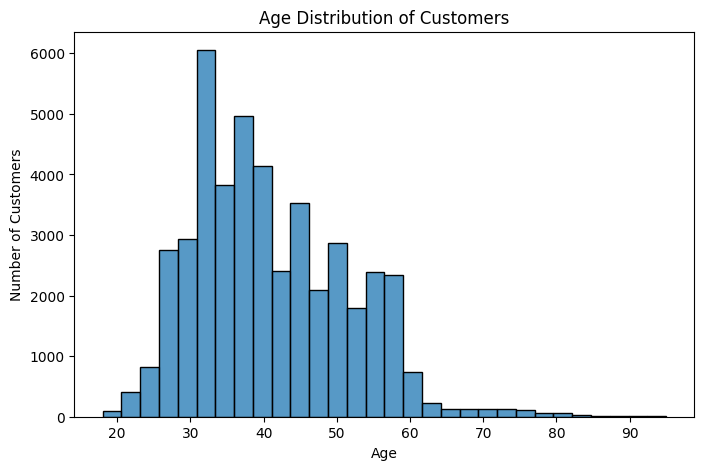

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="age", bins=30)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

### Job Distribution 

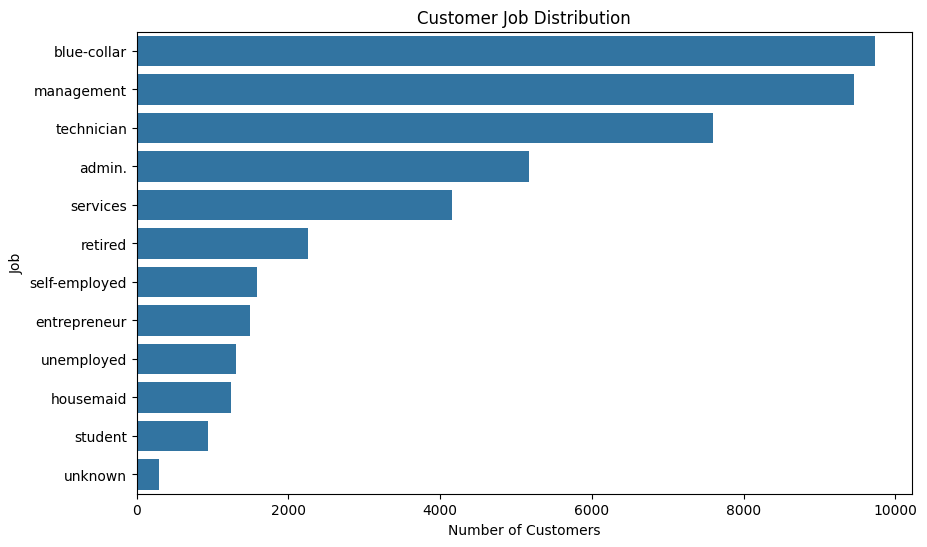

In [28]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="job",
    order=df["job"].value_counts().index
)

plt.title("Customer Job Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Job")

plt.show()

### Subscription by Housing Loan

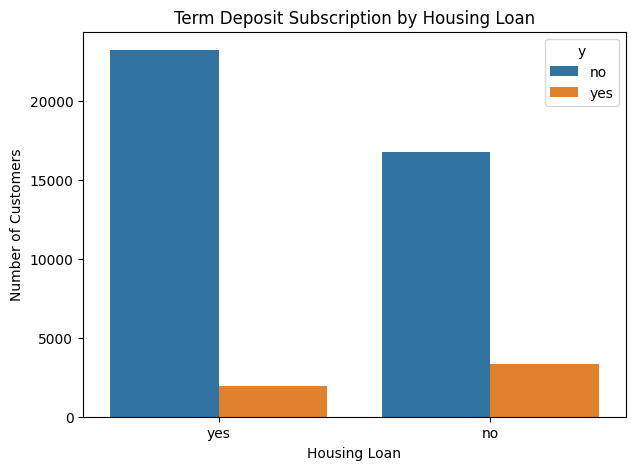

In [35]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="housing",
    hue="y"
)

plt.title("Term Deposit Subscription by Housing Loan")
plt.xlabel("Housing Loan")
plt.ylabel("Number of Customers")

plt.show()

### Subscription by Personal Loan

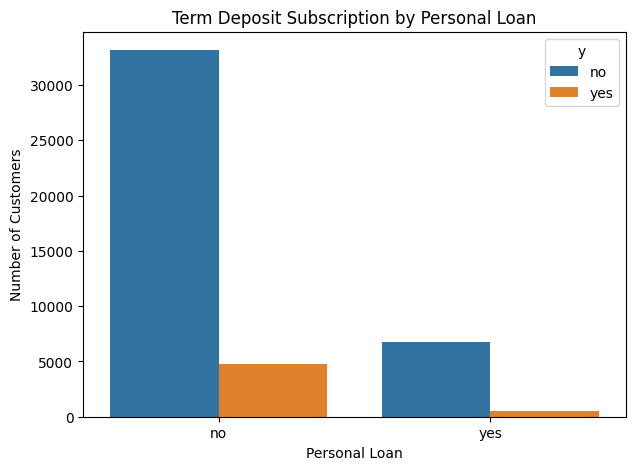

In [36]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="loan",
    hue="y"
)

plt.title("Term Deposit Subscription by Personal Loan")
plt.xlabel("Personal Loan")
plt.ylabel("Number of Customers")

plt.show()

### Account Balance Distribution

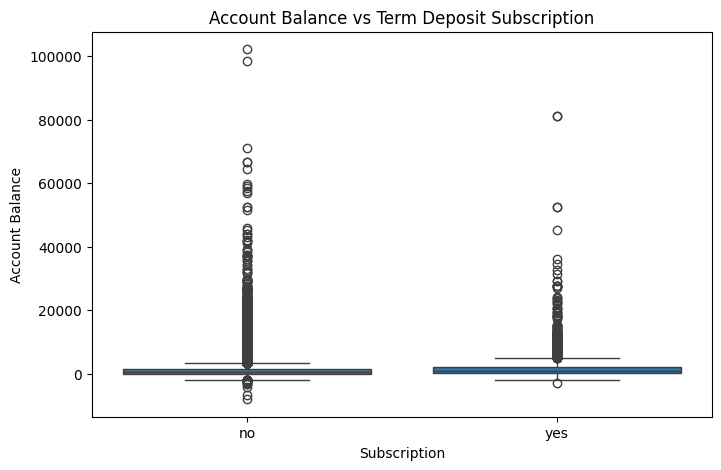

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="y",
    y="balance"
)

plt.title("Account Balance vs Term Deposit Subscription")
plt.xlabel("Subscription")
plt.ylabel("Account Balance")

plt.show()

# Data Preprocessing
duration represents the length of the current marketing call. If we're trying to predict whether someone will subscribe as part of the campaign, call duration is information that becomes known during/after the call and can create data leakage.

In [38]:
df_model = df.drop(columns=["duration"])

In [39]:
print("Original columns:", len(df.columns))
print("Model columns:", len(df_model.columns))

Original columns: 17
Model columns: 16


### Separate Features and Target

In [ ]:
X = df_model.drop("y", axis=1)
y = df_model["y"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (45211, 15)
Target shape: (45211,)


### Convert Target to Numerical Values

In [44]:
y = y.map({
    "no": 0,
    "yes": 1
})

print(y.value_counts())

Series([], Name: count, dtype: int64)


### Encode Categorical Variables

In [52]:
print("df y:")
print(df["y"].unique())

print("\ndf_model y:")
print(df_model["y"].unique())

print("\ndf_model y counts:")
print(df_model["y"].value_counts(dropna=False))

df y:
['no' 'yes']

df_model y:
['no' 'yes']

df_model y counts:
y
no     39922
yes     5289
Name: count, dtype: int64


In [53]:
# Create a fresh copy for modelling
df_model = df.copy()

# Remove duration to avoid potential data leakage
df_model = df_model.drop(columns=["duration"])

# Separate features and target
X = df_model.drop("y", axis=1)

y = df_model["y"]

# Encode target
y = y.map({
    "no": 0,
    "yes": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing values in y:", y.isnull().sum())

X shape: (45211, 15)
y shape: (45211,)

Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64

Missing values in y: 0


In [54]:
X = pd.get_dummies(X, drop_first=True)

In [55]:
print("X shape after encoding:", X.shape)
print("Missing values in X:", X.isnull().sum().sum())

X shape after encoding: (45211, 41)
Missing values in X: 0


print(y.value_counts())

In [57]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


## 7. Train-Test Split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (36168, 41)
Testing features: (9043, 41)
Training target: (36168,)
Testing target: (9043,)


### Build the Decision Tree

In [60]:
model = DecisionTreeClassifier(
    random_state=42
)

### Train the Model

In [61]:
model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [62]:
y_pred = model.predict(X_test)

In [63]:
print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0]


### Accuracy Calculation 

In [64]:
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy)
print("Decision Tree Accuracy (%):", accuracy * 100)

Decision Tree Accuracy: 0.8302554462014818
Decision Tree Accuracy (%): 83.02554462014818


### Classification Report 

In [65]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No", "Yes"]
))

Classification Report:
              precision    recall  f1-score   support

          No       0.91      0.90      0.90      7985
         Yes       0.30      0.33      0.31      1058

    accuracy                           0.83      9043
   macro avg       0.60      0.61      0.61      9043
weighted avg       0.84      0.83      0.83      9043



### Confusion Matrix 

In [66]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7158  827]
 [ 708  350]]


### Visualization 

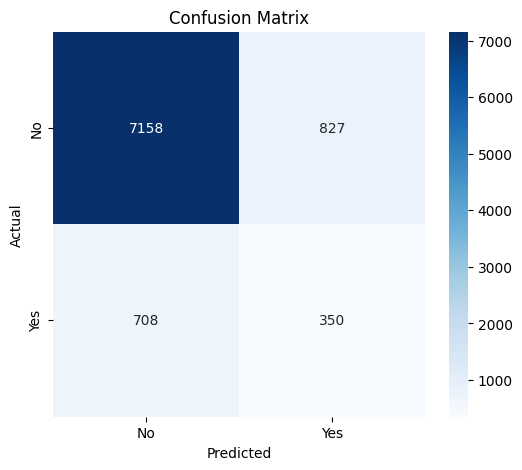

In [67]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Training Vs Testing Accuracy 

In [70]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.8302554462014818


In [ ]:
baseline_predictions = np.zeros(len(y_test))

baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Accuracy (%):", baseline_accuracy * 100)

Baseline Accuracy: 0.8830034280659074
Baseline Accuracy (%): 88.30034280659073


In [72]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No", "Yes"]
))

              precision    recall  f1-score   support

          No       0.91      0.90      0.90      7985
         Yes       0.30      0.33      0.31      1058

    accuracy                           0.83      9043
   macro avg       0.60      0.61      0.61      9043
weighted avg       0.84      0.83      0.83      9043



## Model Evaluation

The initial Decision Tree achieved **83.03% test accuracy**, while the baseline model that always predicts `No` achieved **88.30% accuracy**.

The model performed well for the `No` class but poorly for the `Yes` class:

- Precision (`Yes`): **0.30**
- Recall (`Yes`): **0.33**
- F1-score (`Yes`): **0.31**

This shows that accuracy alone is not sufficient because the dataset is imbalanced. The model struggles to identify customers who actually subscribe.

The Decision Tree also achieved **100% training accuracy**, suggesting possible **overfitting**. Therefore, we will tune the model to improve its ability to generalize to unseen data.

## Model Tuning

The Decision Tree will be tuned by controlling its complexity using parameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf` to reduce overfitting.

In [73]:
tuned_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

In [74]:
tuned_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [75]:
y_pred_tuned = tuned_model.predict(X_test)

In [76]:
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Tuned Training Accuracy:", tuned_model.score(X_train, y_train))
print("Tuned Testing Accuracy:", tuned_accuracy)

Tuned Training Accuracy: 0.8995244414952445
Tuned Testing Accuracy: 0.8935087913303107


In [77]:
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["No", "Yes"]
))

              precision    recall  f1-score   support

          No       0.90      0.98      0.94      7985
         Yes       0.63      0.21      0.32      1058

    accuracy                           0.89      9043
   macro avg       0.77      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043



In [78]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(cm_tuned)

[[7854  131]
 [ 832  226]]


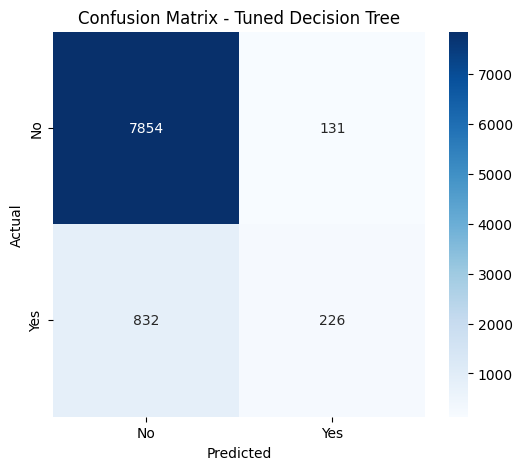

In [79]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Confusion Matrix - Tuned Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [80]:
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["No", "Yes"]
))

              precision    recall  f1-score   support

          No       0.90      0.98      0.94      7985
         Yes       0.63      0.21      0.32      1058

    accuracy                           0.89      9043
   macro avg       0.77      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043



## Tuned Model Evaluation

The tuned Decision Tree achieved **89.35% testing accuracy**, improving significantly over the original model's 83.03% accuracy. The training accuracy also decreased from 100% to 89.95%, indicating reduced overfitting.

However, the recall for the `Yes` class decreased to **0.21**. This means the model identifies only about 21% of customers who actually subscribed.

Therefore, although the tuned model performs better in terms of overall accuracy and generalization, it is still limited in identifying potential subscribers.

### Feature Importance

In [81]:
tuned_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tuned_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

tuned_importance.head(15)

,Feature,Importance
39,poutcome_success,0.472664
0,age,0.095680
4,pdays,0.080145
26,contact_unknown,0.056218
32,month_jun,0.053137
33,month_mar,0.046607
36,month_oct,0.043988
2,day,0.036235
37,month_sep,0.031786
1,balance,0.031655


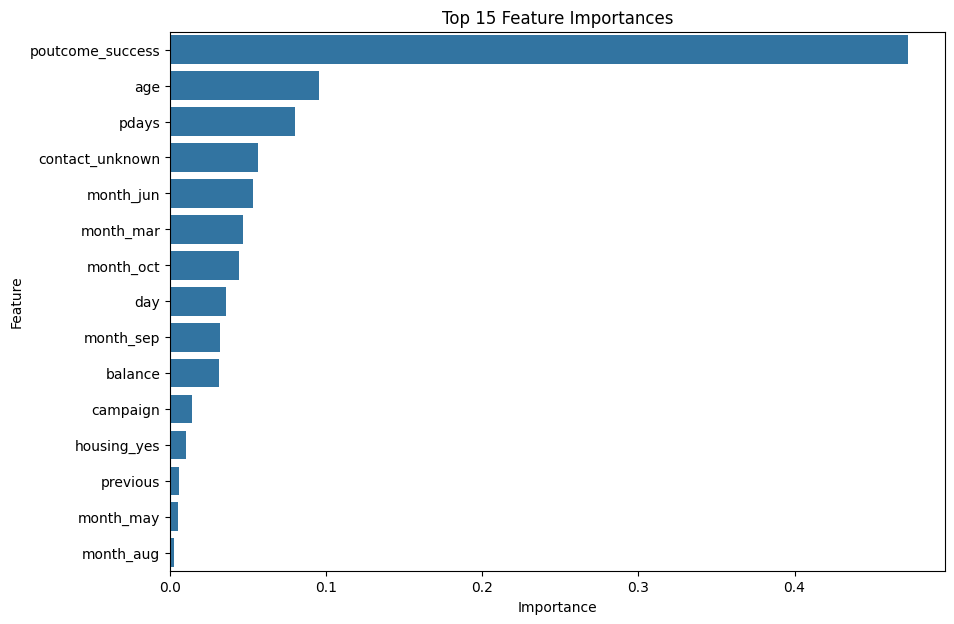

In [82]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=tuned_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Feature Importance

The feature importance analysis shows that `poutcome_success` is the most influential feature in the tuned Decision Tree, followed by `age`, `pdays`, and several campaign-related variables.

The results suggest that previous campaign outcomes and customer characteristics play an important role in predicting term-deposit subscription.

However, feature importance indicates how useful a feature was to the Decision Tree, not that the feature directly causes a customer to subscribe.

## Decision Tree Visualization

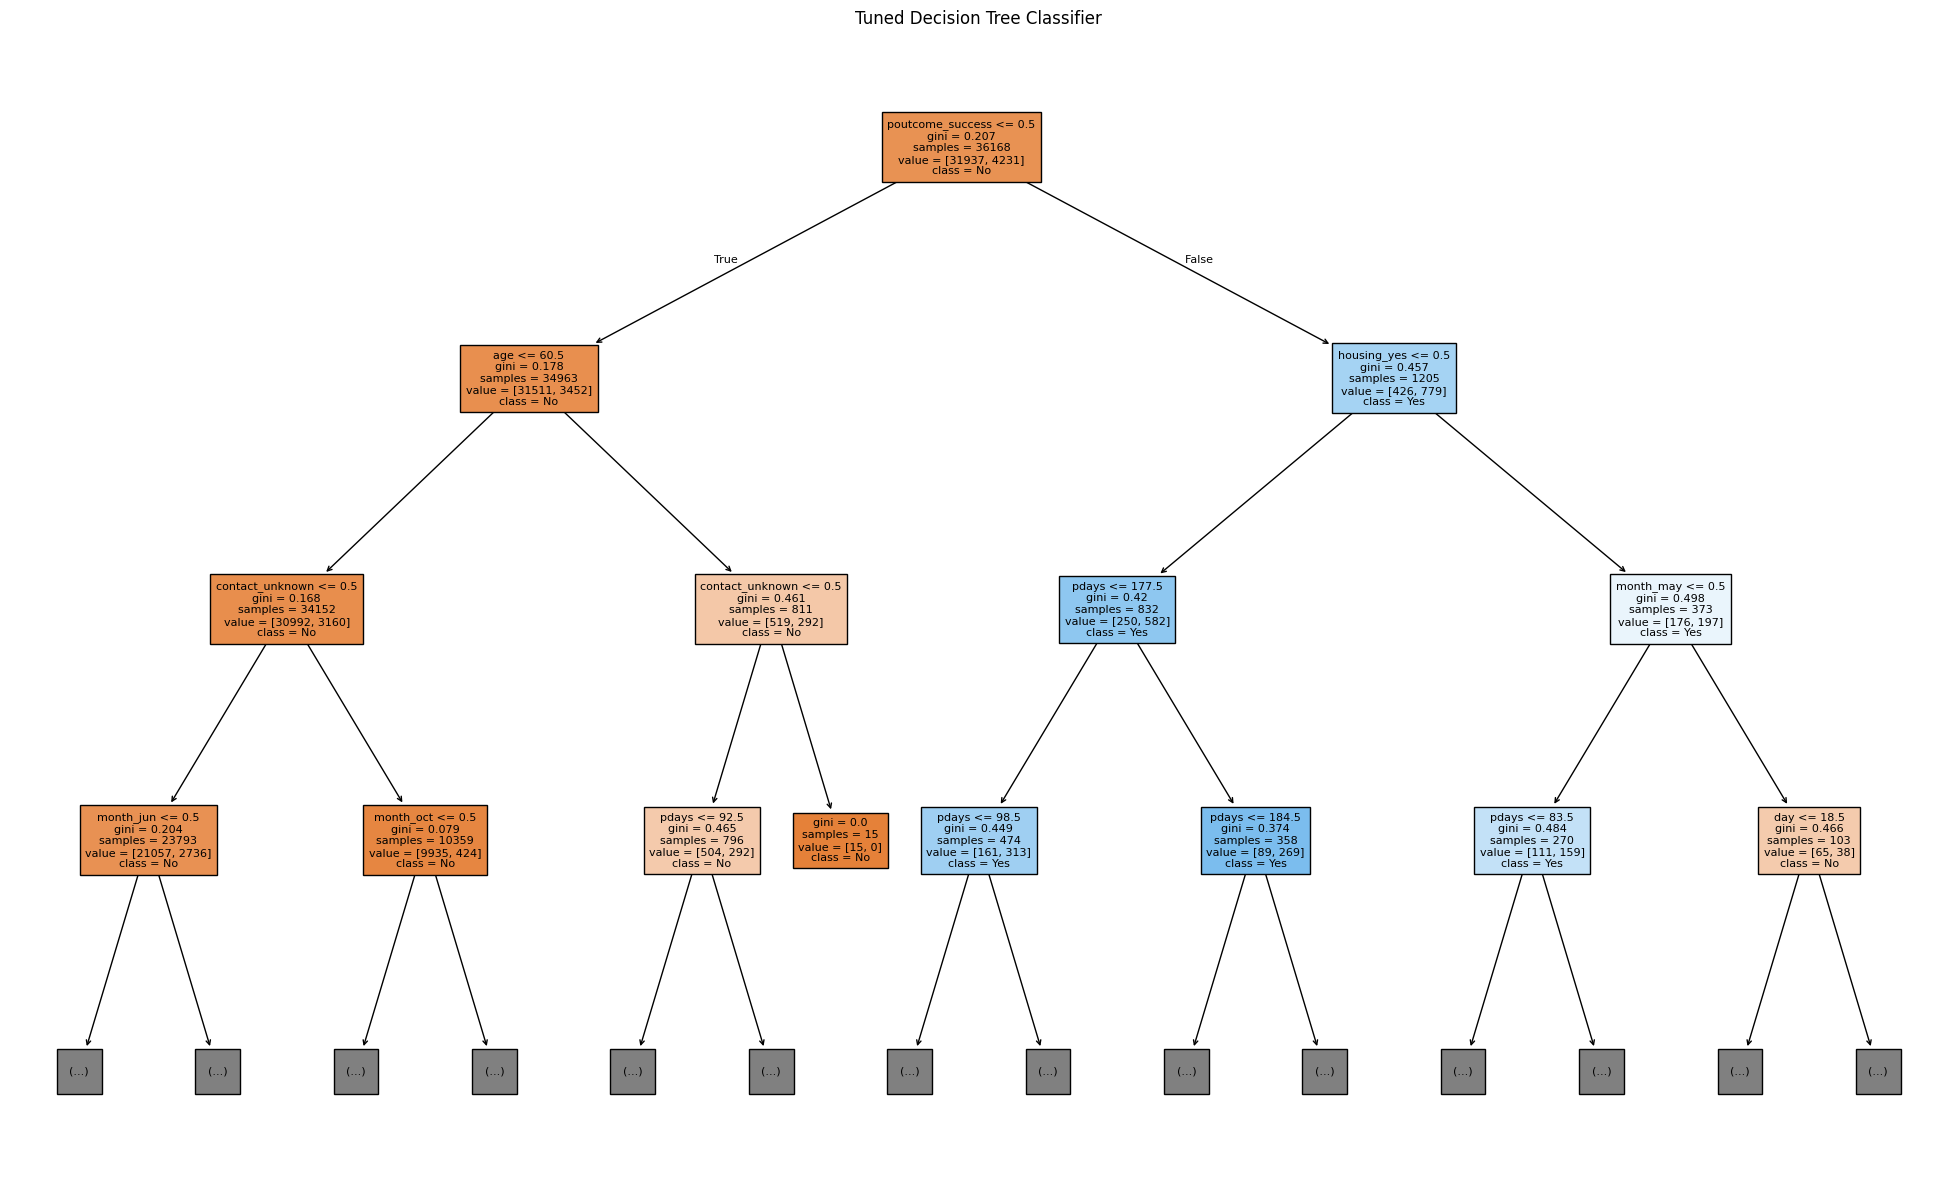

In [83]:
plt.figure(figsize=(25, 15))

plot_tree(
    tuned_model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Tuned Decision Tree Classifier")
plt.show()

## Decision Tree Visualization Interpretation

The visualization shows how the tuned Decision Tree makes predictions using different customer characteristics.

The first split is based on `poutcome_success`, indicating that the previous campaign outcome is an important factor in the prediction. Other important splits include `age`, `housing`, `pdays`, `contact_unknown`, and `month`.

The tree has been limited to a depth of 3 in the visualization to make the main decision rules easier to understand.

# Conclusion

A Decision Tree Classifier was developed to predict whether a customer would subscribe to a bank term deposit.

The original model achieved **83.03% test accuracy** but showed signs of overfitting, with **100% training accuracy**. After tuning the tree, the training accuracy decreased to **89.95%** while test accuracy improved to **89.35%**, indicating better generalization.

However, the tuned model achieved only **21% recall for the `Yes` class**, meaning many potential subscribers were still missed.

Feature importance showed that `poutcome_success`, `age`, `pdays`, and contact-related features were among the most influential variables.

Overall, the Decision Tree demonstrates that customer demographic and campaign-related information can be used to predict term-deposit subscription, although further model improvement would be needed for effective marketing use.